# Bike Demand Prediction Using Machine Learning

This project predicts hourly bike rental demand using weather and time-related data.

**Models:** Linear Regression and Random Forest Regressor  
**Metrics:** RMSE and R² Score


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


## 2. Load the Dataset

In [2]:
df = pd.read_csv(
    "SeoulBikeData.csv",
    encoding="unicode_escape"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 3. Data Preprocessing

### 3.1 Rename Columns

In [3]:
df = df.rename(columns={
    "Rented Bike Count": "Rented_Bike_Count",
    "Temperature(°C)": "Temperature",
    "Humidity(%)": "Humidity",
    "Wind speed (m/s)": "Wind_Speed",
    "Visibility (10m)": "Visibility",
    "Dew point temperature(°C)": "Dew_Point_Temperature",
    "Solar Radiation (MJ/m2)": "Solar_Radiation",
    "Rainfall(mm)": "Rainfall",
    "Snowfall (cm)": "Snowfall",
    "Functioning Day": "Functioning_Day"
})

df.columns

Index(['Date', 'Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity',
       'Wind_Speed', 'Visibility', 'Dew_Point_Temperature', 'Solar_Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning_Day'],
      dtype='str')

### 3.2 Create Date Features

In [4]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y"
)

df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

df[["Date", "Month", "Day", "Weekday"]].head()

,Date,Month,Day,Weekday
0,2017-12-01,12,1,Friday
1,2017-12-01,12,1,Friday
2,2017-12-01,12,1,Friday
3,2017-12-01,12,1,Friday
4,2017-12-01,12,1,Friday


### 3.3 Encode Categorical Columns

In [5]:
df = pd.get_dummies(
    df,
    columns=[
        "Seasons",
        "Holiday",
        "Functioning_Day"
    ],
    drop_first=False
)

df.head()

,Date,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point_Temperature,Solar_Radiation,Rainfall,...,Day,Weekday,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning_Day_No,Functioning_Day_Yes
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,1,Friday,False,False,False,True,False,True,False,True
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,1,Friday,False,False,False,True,False,True,False,True
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,1,Friday,False,False,False,True,False,True,False,True
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,1,Friday,False,False,False,True,False,True,False,True
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,1,Friday,False,False,False,True,False,True,False,True


### 3.4 Create Day Type

Days are divided into:

- **Work:** normal weekdays
- **Leisure:** weekends or official holidays

In [6]:
is_weekend = df["Weekday"].isin([
    "Saturday",
    "Sunday"
])

is_holiday = (
    df["Holiday_Holiday"] == True
)

df["Day_Type"] = np.where(
    is_weekend | is_holiday,
    "Leisure",
    "Work"
)

df[[
    "Weekday",
    "Holiday_Holiday",
    "Day_Type"
]].head(10)

,Weekday,Holiday_Holiday,Day_Type
0,Friday,False,Work
1,Friday,False,Work
2,Friday,False,Work
3,Friday,False,Work
4,Friday,False,Work
5,Friday,False,Work
6,Friday,False,Work
7,Friday,False,Work
8,Friday,False,Work
9,Friday,False,Work


In [7]:
df = pd.get_dummies(
    df,
    columns=["Day_Type"],
    drop_first=False
)

df[[
    "Day_Type_Leisure",
    "Day_Type_Work"
]].head()

,Day_Type_Leisure,Day_Type_Work
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


### 3.5 Remove Unused Columns

In [8]:
df = df.drop(columns=[
    "Date",
    "Dew_Point_Temperature",
    "Weekday"
])

print("Missing values:", df.isnull().sum().sum())
print("Prepared dataset shape:", df.shape)

Missing values: 0
Prepared dataset shape: (8760, 21)


## 4. Exploratory Data Analysis


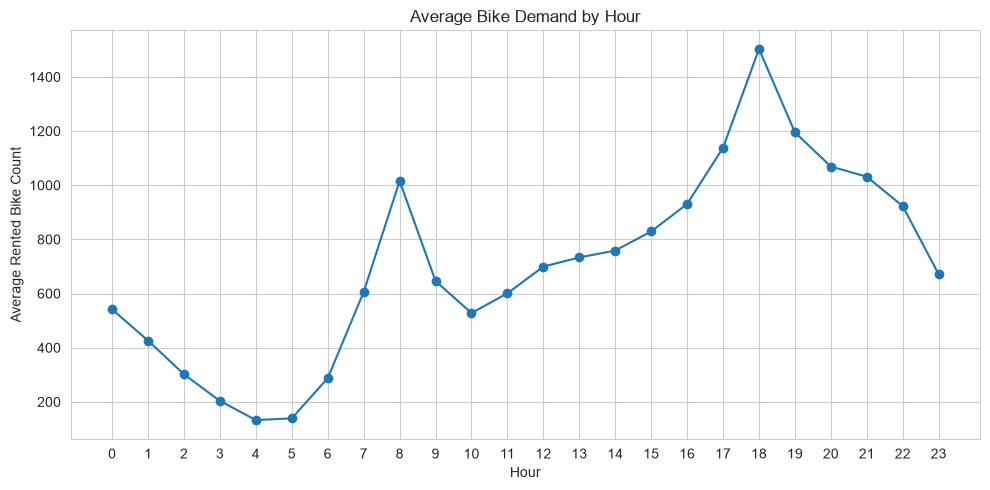

In [9]:
hourly_demand = df.groupby("Hour")["Rented_Bike_Count"].mean()

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


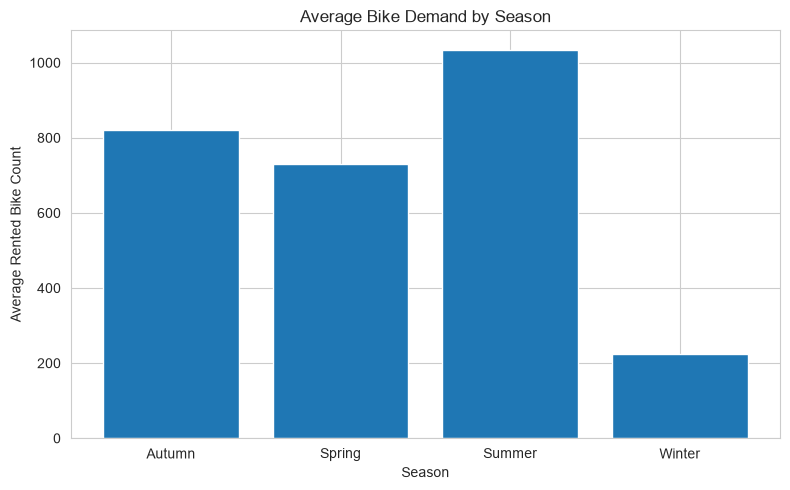

Autumn     819.597985
Spring     730.031250
Summer    1034.073370
Winter     225.541204
dtype: float64

In [10]:
season_columns = [
    "Seasons_Autumn",
    "Seasons_Spring",
    "Seasons_Summer",
    "Seasons_Winter"
]

seasonal_demand = {
    column.replace("Seasons_", ""):
    df.loc[df[column] == True, "Rented_Bike_Count"].mean()
    for column in season_columns
}

seasonal_demand = pd.Series(seasonal_demand)

plt.figure(figsize=(8, 5))
plt.bar(
    seasonal_demand.index,
    seasonal_demand.values
)
plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

seasonal_demand


In [11]:
numeric_df = df.select_dtypes(include=np.number)

target_correlations = (
    numeric_df.corr()["Rented_Bike_Count"]
    .sort_values(ascending=False)
    .head(10)
)

target_correlations


Rented_Bike_Count    1.000000
Temperature          0.538558
Hour                 0.410257
Solar_Radiation      0.261837
Visibility           0.199280
Month                0.133514
Wind_Speed           0.121108
Day                  0.022291
Rainfall            -0.123074
Snowfall            -0.141804
Name: Rented_Bike_Count, dtype: float64

## 5. Train the Models


In [12]:
X = df.drop(columns=["Rented_Bike_Count"]).astype(float)
y = df["Rented_Bike_Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (6570, 20)
Testing data: (2190, 20)


In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 6. Evaluate the Models


In [14]:
linear_predictions = linear_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)
linear_r2 = r2_score(y_test, linear_predictions)

random_forest_rmse = np.sqrt(
    mean_squared_error(y_test, random_forest_predictions)
)
random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse
    ],
    "R2": [
        linear_r2,
        random_forest_r2
    ]
})

results


,Model,RMSE,R2
0,Linear Regression,435.576477,0.536348
1,Random Forest,170.863976,0.928655


In [15]:
best_model = results.sort_values("RMSE").iloc[0]

print("Best Model:", best_model["Model"])
print("RMSE:", round(best_model["RMSE"], 2))
print("R²:", round(best_model["R2"], 4))


Best Model: Random Forest
RMSE: 170.86
R²: 0.9287


## 7. Random Forest Feature Importance


In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)


,Feature,Importance
1,Temperature,0.306140
0,Hour,0.290523
5,Solar_Radiation,0.088663
2,Humidity,0.075352
17,Functioning_Day_Yes,0.046753
16,Functioning_Day_No,0.043141
6,Rainfall,0.038192
19,Day_Type_Work,0.017970
18,Day_Type_Leisure,0.017915
8,Month,0.015243


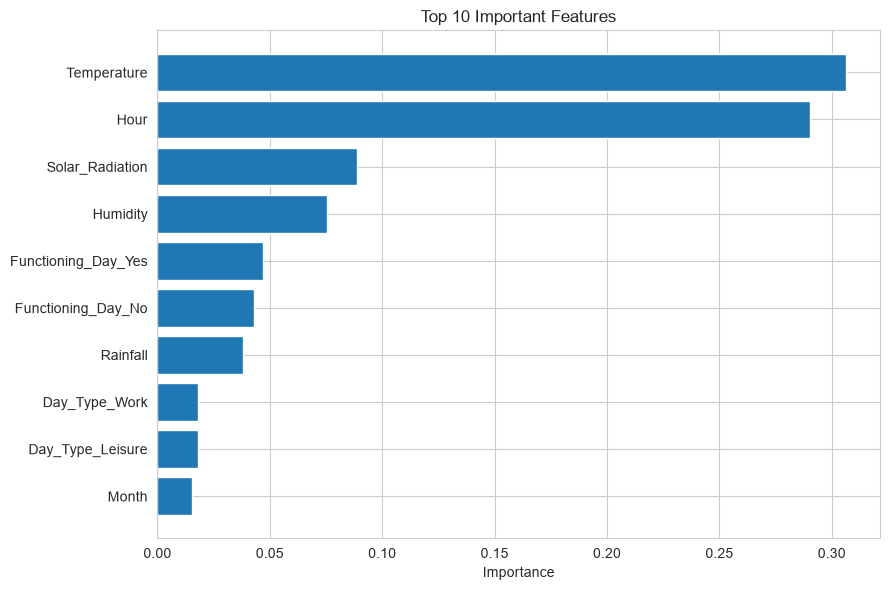

In [17]:
top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. Real-World Test Scenario

**Scenario:** Monday in Summer, July 2, 8:00 AM, 25°C, and no rain.

Additional values:

- Humidity: 60%
- Wind speed: 1.5 m/s
- Visibility: 1500
- Solar radiation: 0.5
- No snowfall
- Not a holiday
- Functioning day

In [18]:
# Create one row with the same columns used to train the models
scenario_data = {
    column: 0
    for column in X.columns
}

# Original scenario values
scenario_data.update({
    "Hour": 8,
    "Temperature": 25,
    "Humidity": 60,
    "Wind_Speed": 1.5,
    "Visibility": 1500,
    "Solar_Radiation": 0.5,
    "Rainfall": 0,
    "Snowfall": 0,

    "Month": 7,
    "Day": 2,

    "Seasons_Summer": 1,

    "Holiday_Holiday": 0,
    "Holiday_No Holiday": 1,

    "Functioning_Day_No": 0,
    "Functioning_Day_Yes": 1,

    "Day_Type_Leisure": 0,
    "Day_Type_Work": 1
})

scenario_df = pd.DataFrame(
    [scenario_data],
    columns=X.columns
)

scenario_df

,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Month,Day,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning_Day_No,Functioning_Day_Yes,Day_Type_Leisure,Day_Type_Work
0,8,25,60,1.5,1500,0.5,0,0,7,2,0,0,1,0,0,1,0,1,0,1


In [19]:
linear_scenario_prediction = linear_model.predict(
    scenario_df
)[0]

random_forest_scenario_prediction = (
    random_forest_model.predict(scenario_df)[0]
)

print("--- Real-World Prediction Comparison ---")
print("Conditions: Summer Monday, 8:00 AM, 25°C, No Rain")
print(
    "Linear Regression Prediction:",
    round(max(linear_scenario_prediction, 0)),
    "bikes"
)
print(
    "Random Forest Prediction:",
    round(max(random_forest_scenario_prediction, 0)),
    "bikes"
)


--- Real-World Prediction Comparison ---
Conditions: Summer Monday, 8:00 AM, 25°C, No Rain
Linear Regression Prediction: 1005 bikes
Random Forest Prediction: 1988 bikes


## 9. Conclusion


In [20]:
print(
    f"Random Forest achieved an R² score of "
    f"{random_forest_r2:.4f} and an RMSE of "
    f"{random_forest_rmse:.2f}."
)

print(
    "It performed better than Linear Regression "
    "for this dataset."
)


Random Forest achieved an R² score of 0.9287 and an RMSE of 170.86.
It performed better than Linear Regression for this dataset.
